# Predicting Late Delivery Risk with Logistic Regression

This notebook builds a logistic regression model to predict whether an order is at risk of a late delivery. It uses shipping mode, scheduled delivery days, customer region, and product category as input features. The goal is to see how well these factors can predict which orders will be flagged as high-risk before they ship.

## Setup

The cell below imports the required libraries, connects to the SQLite database, and defines a helper function called `run_query_to_df` that runs a SQL query and returns the results as a pandas DataFrame.

In [27]:
# Import necessary libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

print("Libraries imported successfully!")

# Connect to the SQLite database
conn = sqlite3.connect("inventory.db")

# Create a cursor object to interact with the database
cursor = conn.cursor()

# Function to run a SQL query and return the results as a DataFrame
def run_query_to_df(cursor, query):
    cursor.execute(query)
    rows = cursor.fetchall()
    
    # Get column names from cursor
    columns = []
    for col in cursor.description:
        columns.append(col[0])

    # Convert to DataFrame
    df = pd.DataFrame(rows, columns = columns)

    return df

Libraries imported successfully!


## Pulling the Training Data

This query fetches the features we will use to train the model: shipping mode, scheduled delivery days, customer market region, product category, and the late delivery risk flag. The late delivery risk column is the target variable, where 1 means the order was flagged as at risk and 0 means it was not. All other columns are the inputs the model will learn from.

In [28]:
query = """
SELECT s.shipping_mode, s.days_scheduled, cu.market AS region, cat.category_name, s.late_delivery_risk
FROM orders o
JOIN order_items oi  ON o.id = oi.order_id
JOIN shipping s      ON o.id = s.order_id
JOIN products p      ON oi.product_id = p.id
JOIN customers cu    ON o.customer_id = cu.id
JOIN categories cat  ON p.category_id = cat.id
"""

# Call the function to run the query and display results
data = run_query_to_df(cursor, query)
data

,shipping_mode,days_scheduled,region,category_name,late_delivery_risk
0,Standard Class,4.0,LATAM,Camping & Hiking,0
1,Standard Class,4.0,Africa,Water Sports,0
2,Standard Class,4.0,Africa,Women's Apparel,0
3,Standard Class,4.0,Africa,Men's Footwear,0
4,Standard Class,4.0,LATAM,Accessories,1
...,...,...,...,...,...
171957,Standard Class,4.0,Europe,Indoor/Outdoor Games,0
171958,Standard Class,4.0,Europe,Women's Apparel,0
171959,Standard Class,4.0,Europe,Cardio Equipment,0
171960,Standard Class,4.0,Europe,Strength Training,0


## Building the Logistic Regression Model

This cell prepares the data and trains the model. First, categorical columns like shipping mode and region are converted to numeric values using one-hot encoding with `pd.get_dummies`. The data is then split into a training set (80%) and a test set (20%). Features are scaled with `StandardScaler` so columns with larger numeric ranges do not dominate the model. A logistic regression model is trained on the training data with `class_weight='balanced'` to handle any imbalance between the two outcome classes. Predictions are made on the test set and the overall accuracy and a full classification report are printed.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Convert categorical text columns to numeric before scaling
X = pd.get_dummies(data.drop(columns=['late_delivery_risk']), drop_first=True)
y = data['late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.69
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.89      0.72     15454
           1       0.85      0.53      0.66     18939

    accuracy                           0.69     34393
   macro avg       0.73      0.71      0.69     34393
weighted avg       0.74      0.69      0.68     34393



## Confusion Matrix

The confusion matrix breaks down the model's predictions into four groups: true positives (correctly predicted at-risk), true negatives (correctly predicted not at-risk), false positives (predicted at-risk but were not), and false negatives (predicted not at-risk but actually were). Looking at these four numbers together gives a more complete picture of how the model is performing beyond just the overall accuracy score.

Confusion Matrix:
[[13685  1769]
 [ 8844 10095]]


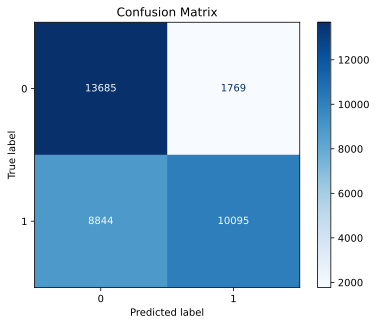

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Optional: Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()